This document is inteded to showcase usage and allow the IBL team to acess example data until we decide about uploading the full dataset. The idea is to iterate and add improvements to the structure, suggest visualization and data access patterns that might be desirable for the final documentation.

To use it, you will need to run this notebook in an environment that has both pynwb and remfile installed plus any additional dependencies that we use for analysis such as matplotib, numpy, pandas, etc.

# Locate Examples

In [25]:
import h5py
import remfile
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient

# Connect to DANDI and get the dandiset
dandiset_id = "000409"
client = DandiAPIClient()
dandiset = client.get_dandiset(dandiset_id, "draft")

# =============================================================================
# Session EIDs for NEW format files (desc-raw / desc-processed)
# =============================================================================

# Complete session with 2 probes - Session 1 (NYU-39, 2021-05-10, angelakilab)
# - Full data: all videos, pose estimation, spike sorting for both probes
TWO_PROBE_SESSION_EID_1 = "6ed57216-498d-48a6-b48b-a243a34710ea"

# Complete session with 2 probes - Session 2 (NYU-39, 2021-05-11, angelakilab)
# - Full data: all videos, pose estimation, spike sorting for both probes
TWO_PROBE_SESSION_EID_2 = "35ed605c-1a1a-47b1-86ff-2b56144f55af"

# Complete session with 1 probe (NYU-46, 2021-06-25, angelakilab)  
# - Full data: all videos, pose estimation, spike sorting for probe01
ONE_PROBE_SESSION_EID = "64e3fb86-928c-4079-865c-b364205b502e"

# Choose which session to use
session_eid = TWO_PROBE_SESSION_EID_1  # Change to TWO_PROBE_SESSION_EID_2 or ONE_PROBE_SESSION_EID
session_eid = "78b4fff5-c5ec-44d9-b5f9-d59493063f00"
# session_eid = "196a2adf-ff83-49b2-823a-33f990049c2"

# =============================================================================
# Fetch assets by EID
# =============================================================================

# First, filter assets by EID
session_assets = [asset for asset in dandiset.get_assets() if session_eid in asset.path]

# Then, extract raw and processed files
raw_asset = next((asset for asset in session_assets if "desc-raw" in asset.path), None)
processed_asset = next((asset for asset in session_assets if "desc-processed" in asset.path), None)

print(f"Session EID: {session_eid}")
print(f"\nRaw file:       {raw_asset.path if raw_asset else 'Not found'}")
print(f"Processed file: {processed_asset.path if processed_asset else 'Not found'}")

Session EID: 78b4fff5-c5ec-44d9-b5f9-d59493063f00

Raw file:       sub-KS091/sub-KS091_ses-78b4fff5-c5ec-44d9-b5f9-d59493063f00_desc-raw_ecephys.nwb
Processed file: Not found


# Raw NWB file 
The raw data is stored in a separate file from the processed data. The raw data file contains the acquisition module with the raw ephys data (both AP and LF bands); video metadata (which includes properly aligned timestamps) and a link to the video files; and, when available, the NIDQ board data.

In [26]:
s3_url = raw_asset.get_content_url(follow_redirects=1, strip_query=False)
file_system = remfile.File(s3_url)
file = h5py.File(file_system, mode="r")

io = NWBHDF5IO(file=file)
nwbfile_raw = io.read()

In [27]:
nwbfile_raw.session_start_time

datetime.datetime(2022, 7, 4, 14, 30, 15, 49000, tzinfo=tzoffset(None, 3600))

In [28]:
devices = nwbfile_raw.devices
probe_devices = [devices[name] for name in devices if "Probe" in name]
for probe_device in probe_devices:
    print(f"{probe_device.name}: {probe_device.serial_number}")



Probe00: 18005102151
Probe01: 18194814141


In [ ]:
Probe00: 18005102151
Probe01: 18194814141

In [ ]:
nwbfile_raw

Data type,int16
Shape,"(164362247, 384)"
Array size,117.56 GiB
Chunk shape,"(13020, 384)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),126230205696
Compressed size (bytes),61453524661
Compression ratio,2.0540759279851195
Data type,float64
Shape,"(164362247,)"


## Locating and Accessing the AP and LF bands

The raw data is stored in the acquisition module as an ElectricalSeries. We can access the AP bands of each probe as follows and use the HTML representation to display the metada of the ElectricalSeries

In [29]:
probe_00_ap_series = nwbfile_raw.acquisition["ElectricalSeriesProbe00AP"]
probe_01_ap_series = nwbfile_raw.acquisition["ElectricalSeriesProbe01AP"]

probe_00_ap_series

Data type,int16
Shape,"(164362247, 384)"
Array size,117.56 GiB
Chunk shape,"(13020, 384)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),126230205696
Compressed size (bytes),61453524661
Compression ratio,2.0540759279851195
Data type,float64
Shape,"(164362247,)"


The LF bands can be accessed in a similar way:

In [30]:
probe_00_lf_series = nwbfile_raw.acquisition["ElectricalSeriesProbe00LF"]
probe_01_lf_series = nwbfile_raw.acquisition["ElectricalSeriesProbe01LF"]

probe_01_lf_series

Data type,int16
Shape,"(13696867, 384)"
Array size,9.80 GiB
Chunk shape,"(13020, 384)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),10519193856
Compressed size (bytes),5387497680
Compression ratio,1.9525194219666002
Data type,float64
Shape,"(13696867,)"


Each of the ElectricalSeries has its own timestamps that are aligned to the common clock used across the entire NWB file. Each of the ElectricalSeries is linked to the corresponding probe metadata stored in the electrodes table. For example, we can access the electrodes table for probe 0 as follows:

In [31]:
probe_01_ap_series.electrodes.to_dataframe()

,location,group,electrode_name,contact_shapes,channel_name,rel_x,rel_y,probe_name,contact_ids,shank_ids,adc_group,adc_sample_order,group_name,x,y,z,imp,filtering
id,,,,,,,,,,,,,,,,,,
0,Infralimbic area layer 1,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e0,square,"AP0,LF0",16.0,0.0,Probe01,e0,,0,0,Probe01,3401.0,4105.0,5751.0,NaN,
1,Infralimbic area layer 1,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e1,square,"AP1,LF1",48.0,0.0,Probe01,e1,,1,0,Probe01,3401.0,4105.0,5751.0,NaN,
2,Infralimbic area layer 1,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e2,square,"AP2,LF2",0.0,20.0,Probe01,e2,,0,1,Probe01,3401.0,4087.0,5745.0,NaN,
3,Infralimbic area layer 1,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e3,square,"AP3,LF3",32.0,20.0,Probe01,e3,,1,1,Probe01,3401.0,4087.0,5745.0,NaN,
4,Infralimbic area layer 1,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e4,square,"AP4,LF4",16.0,40.0,Probe01,e4,,0,2,Probe01,3401.0,4068.0,5739.0,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,void,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e379,square,"AP379,LF379",32.0,3780.0,Probe01,e379,,31,9,Probe01,2973.0,602.0,4744.0,NaN,
380,void,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e380,square,"AP380,LF380",16.0,3800.0,Probe01,e380,,30,10,Probe01,2971.0,583.0,4739.0,NaN,
381,void,Probe01 pynwb.ecephys.ElectrodeGroup at 0x1244...,e381,square,"AP381,LF381",48.0,3800.0,Probe01,e381,,31,10,Probe01,2971.0,583.0,4739.0,NaN,


## Electrode Metadata
The electrodes attribute of an ElectricalSeries defines a region of the electrodes table stored in the NWB file. This table contains metadata about each of the channels recorded by the probe, including their location in the brain, their position in the probe shank, and other relevant information. A convenient way to access this information is to convert the table to a pandas dataframe as follows:

In [32]:
electrodes = nwbfile_raw.electrodes
electrodes

,location,group,electrode_name,contact_shapes,channel_name,rel_x,rel_y,probe_name,contact_ids,shank_ids,adc_group,adc_sample_order,group_name,x,y,z,imp,filtering
id,,,,,,,,,,,,,,,,,,
0,Infralimbic area layer 1,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x124476157813744\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x124475742985040\nFields:\n description: A PRB_1_4_0480_1 probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1""}\n manufacturer: imec\n serial_number: 18194814141\n\n location: Unresolved\n",e0,square,"AP0,LF0",16.0,0.0,Probe01,e0,,0,0,Probe01,3401.0,4105.0,5751.0,NaN,
1,Infralimbic area layer 1,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x124476157813744\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x124475742985040\nFields:\n description: A PRB_1_4_0480_1 probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1""}\n manufacturer: imec\n serial_number: 18194814141\n\n location: Unresolved\n",e1,square,"AP1,LF1",48.0,0.0,Probe01,e1,,1,0,Probe01,3401.0,4105.0,5751.0,NaN,
2,Infralimbic area layer 1,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x124476157813744\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x124475742985040\nFields:\n description: A PRB_1_4_0480_1 probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1""}\n manufacturer: imec\n serial_number: 18194814141\n\n location: Unresolved\n",e2,square,"AP2,LF2",0.0,20.0,Probe01,e2,,0,1,Probe01,3401.0,4087.0,5745.0,NaN,
3,Infralimbic area layer 1,"Probe01 pynwb.ecephys.ElectrodeGroup at 0x124476157813744\nFields:\n description: Electrode group for probe01\n device: Probe01 pynwb.device.Device at 0x124475742985040\nFields:\n description: A PRB_1_4_0480_1 probe. Additional metadata: {""model_name"": ""PRB_1_4_0480_1"", ""manufacturer"": ""imec"", ""port"": ""4"", ""slot"": ""2"", ""part_number"": ""PRB_1_4_0480_1""}\n manufacturer: imec\n serial_number: 18194814141\n\n location: Unresolved\n",e3,square,"AP3,LF3",32.0,20.0,Probe01,e3,,1,1,Probe01,3401.0,4087.0,5745.0,NaN,


DynamicTable objects such as the electrodes table (but also the Units and trials tables) can be easily converted to pandas dataframes for easier access and manipulation.

In [33]:
electrodes_df = electrodes.to_dataframe()
electrodes_df.columns

Index(['location', 'group', 'electrode_name', 'contact_shapes', 'channel_name',
       'rel_x', 'rel_y', 'probe_name', 'contact_ids', 'shank_ids', 'adc_group',
       'adc_sample_order', 'group_name', 'x', 'y', 'z', 'imp', 'filtering'],
      dtype='object')

Specially useful columns includes 'x', 'y', and 'z' which contain the coordinates of each electrode in the Allen CCF space. Where x is the anterior-posterior axis (AP), y is the dorsal-ventral axis (DV), and z is the medial-lateral axis (ML). In addition, the location column contains the full name of the brain region where each electrode is located. Another useful property are the coordinates `rel_x` and `rel_y` which contain the position of each electrode in the probe shank (relative to the probe) and can be used to visualize the probe geometry. Note that all the position columns are in units of micrometers. Finally, the electrode table also contains the probe name which can be used to filter the table by probe.



In [34]:
columns = ["probe_name", "location", "x", "y", "z", "rel_x", "rel_y"]
electrodes_df[columns].sample(n=5)

,probe_name,location,x,y,z,rel_x,rel_y
id,,,,,,,
424,Probe00,Cortical amygdalar area posterior part lateral...,7800.0,6619.0,2618.0,16.0,400.0
35,Probe01,Infralimbic area layer 1,3318.0,3798.0,5688.0,32.0,340.0
759,Probe00,Field CA3,7925.0,3234.0,2984.0,32.0,3740.0
687,Probe00,Ventral part of the lateral geniculate complex,7906.0,3934.0,2892.0,32.0,3020.0
256,Probe01,Secondary motor area layer 2/3,3075.0,1770.0,5100.0,16.0,2560.0


## Anatomical Location
More detailed anatomical location information is stored in the localization module

In [35]:
localization = nwbfile_raw.lab_meta_data["localization"]
localization

localization abc.Localization at 0x124480963385328
Fields:
  anatomical_coordinates_tables: {
    ElectrodesCCFv3 <class 'abc.AnatomicalCoordinatesTable'>,
    ElectrodesIBLBregma <class 'abc.AnatomicalCoordinatesTable'>
  }
  spaces: {
    AllenCCFv3 <class 'abc.AllenCCFv3Space'>,
    IBLBregma <class 'abc.Space'>
  }

These module contains two coordinate tables linking the electrodes to their anatomical locations in the Allen CCF space and in the IBL virtual bregma centered space. As wiht the electrodes table, these tables can be converted to pandas dataframes for easier access and manipulation.

In [36]:
ccf_table_df = localization.anatomical_coordinates_tables["ElectrodesCCFv3"].to_dataframe()
ibl_bregma_table_df = localization.anatomical_coordinates_tables["ElectrodesIBLBregma"].to_dataframe()

ccf_table_df.columns

Index(['x', 'y', 'z', 'localized_entity', 'probe_name', 'brain_region'], dtype='object')

In [37]:
ccf_table_df.sample(n=5)

,x,y,z,localized_entity,probe_name,brain_region
id,,,,,,
563,7824.0,5162.0,2822.0,location ...,Probe00,CA3
542,7819.0,5396.0,2797.0,location ...,Probe00,CA3
335,3010.0,1015.0,4865.0,location ...,Probe01,void
106,3251.0,3135.0,5485.0,location \ id ...,Probe01,PL2/3
557,7824.0,5232.0,2814.0,location ...,Probe00,CA3


The tables provide the localization of each electrode in different coordinate systems and can be used for more detailed anatomical analyses and visualizations. For example, both tables contain the `probe_name` column which can be used to identify the probe associated with each electrode. In addition, the `ElectrodesIBLBregma` contains the localization in the Cosmos and Beryl spaces that should facilitate certain type of analyses and visualizations.

The localized_entity is a dynamic table region that links back to the electrodes table in the NWB file. This allows us to easily access the electrode metadata for each of the localized electrodes.

## Anatomical Location of Probe Structure

We can illustrate  how to combine the information from the anatomical coordinates table with the metadata contained in the electrodes table to create a visualization that combines the relative positions of the electrodes plus the atlas information. This allows us to see what areas does the probe traverse. We use here the Cosmos parcellation for this visualization as that provides an overall and easy view of the probe localization.

Found 2 probe(s): ['Probe00', 'Probe01']


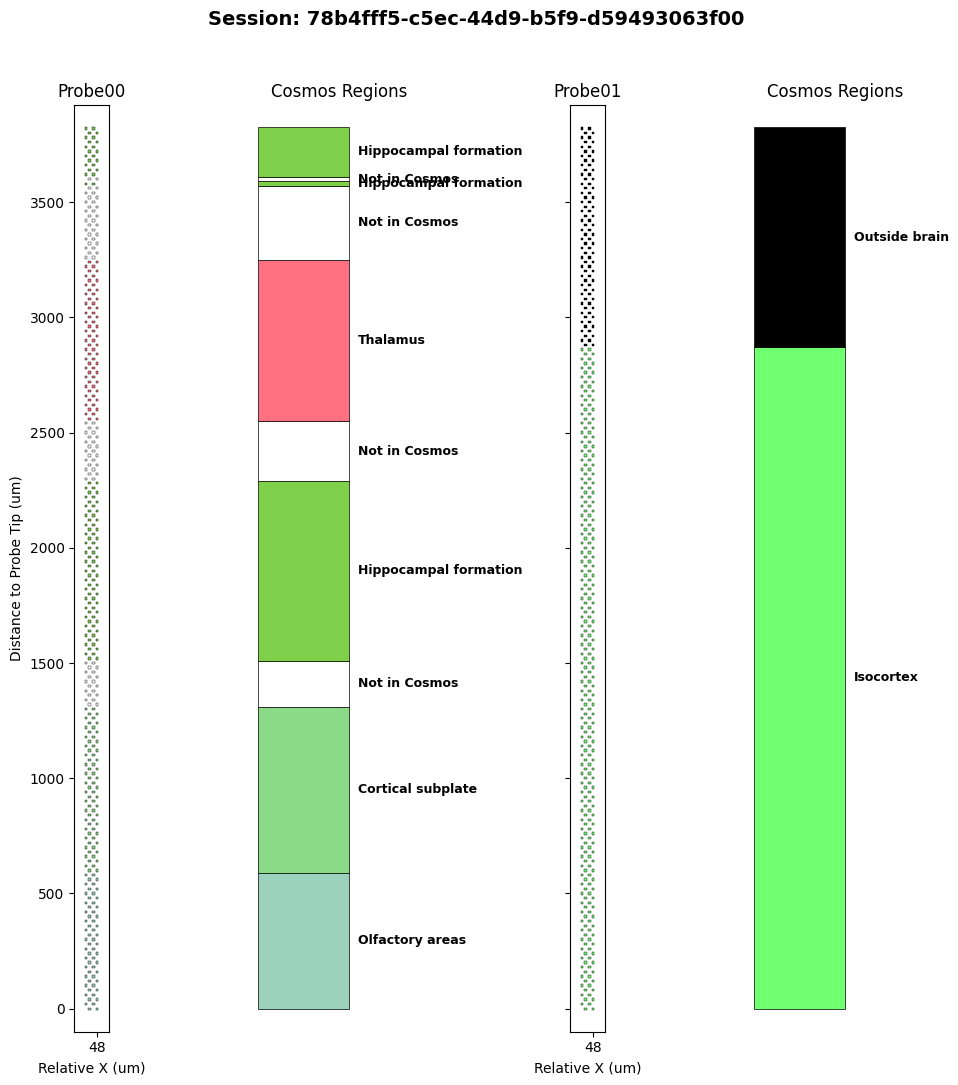

In [38]:
import matplotlib.pyplot as plt

from ibl_to_nwb.utils import COSMOS_FULL_NAMES, get_cosmos_color

nwbfile = nwbfile_raw

# %% Get anatomical localization table
anatomical_tables = localization.anatomical_coordinates_tables
ibl_bregma_table_df = anatomical_tables["ElectrodesIBLBregma"].to_dataframe()

# %% Get all unique probe names
probe_names = sorted(ibl_bregma_table_df["probe_name"].unique())
n_probes = len(probe_names)

print(f"Found {n_probes} probe(s): {probe_names}")

# %% Create figure - 2 columns per probe (contacts + regions), side by side
fig, axes = plt.subplots(1, n_probes * 2, figsize=(5 * n_probes, 12), sharey=True)

# Handle single probe case (axes won't be a list)
if n_probes == 1:
    axes = [axes[0], axes[1]]

# Track all unique regions across all probes for the legend
all_unique_regions = []

# %% Plot each probe
for probe_index, probe_name in enumerate(probe_names):
    # Get axes for this probe
    ax_probe = axes[probe_index * 2]
    ax_regions = axes[probe_index * 2 + 1]

    # Filter data for this probe
    probe_table = ibl_bregma_table_df[ibl_bregma_table_df["probe_name"] == probe_name].copy()

    # Extract electrode positions from localized_entity
    probe_table["rel_x"] = [electrode["rel_x"].iloc[0] for electrode in probe_table["localized_entity"]]
    probe_table["rel_y"] = [electrode["rel_y"].iloc[0] for electrode in probe_table["localized_entity"]]

    # Sort by depth (rel_y)
    probe_table = probe_table.sort_values("rel_y").reset_index(drop=True)

    # Precompute colors
    cosmos_values = probe_table["cosmos_location"].values
    rel_x_values = probe_table["rel_x"].values
    rel_y_values = probe_table["rel_y"].values
    colors = [get_cosmos_color(c) for c in cosmos_values]

    # Track unique regions for legend
    for region in cosmos_values:
        if region not in all_unique_regions:
            all_unique_regions.append(region)

    # --- Left panel: Probe contacts ---
    contact_width = 12  # um
    contact_height = 10  # um

    for i in range(len(rel_x_values)):
        rect = plt.Rectangle(
            (rel_x_values[i] - contact_width / 2, rel_y_values[i] - contact_height / 2),
            contact_width,
            contact_height,
            facecolor=colors[i],
            edgecolor="black",
            linewidth=0.3,
        )
        ax_probe.add_patch(rect)

    # Set probe axis limits
    x_min, x_max = probe_table["rel_x"].min(), probe_table["rel_x"].max()
    y_min, y_max = probe_table["rel_y"].min(), probe_table["rel_y"].max()
    x_margin, y_margin = 50, 100

    ax_probe.set_xlim(x_min - x_margin, x_max + x_margin)
    ax_probe.set_ylim(y_min - y_margin, y_max + y_margin)
    
    # Simplify x-axis: single tick at max value
    ax_probe.set_xticks([x_max])
    ax_probe.set_xticklabels([f"{x_max:.0f}"])
    ax_probe.set_xlabel("Relative X (um)")
    
    if probe_index == 0:
        ax_probe.set_ylabel("Distance to Probe Tip (um)")
    ax_probe.set_title(f"{probe_name}")
    ax_probe.set_aspect("equal", adjustable="box")

    # --- Right panel: Region blocks ---
    blocks = []
    current_region = cosmos_values[0]
    block_start = rel_y_values[0]

    for i in range(1, len(cosmos_values)):
        if cosmos_values[i] != current_region:
            block_end = (rel_y_values[i - 1] + rel_y_values[i]) / 2
            blocks.append((current_region, block_start, block_end))
            current_region = cosmos_values[i]
            block_start = block_end

    # Add final block
    blocks.append((current_region, block_start, rel_y_values[-1] + contact_height / 2))

    # Plot region blocks
    block_width = 1.0
    for region, y_start, y_end in blocks:
        color = get_cosmos_color(region)
        height = y_end - y_start

        rect = plt.Rectangle(
            (0, y_start),
            block_width,
            height,
            facecolor=color,
            edgecolor="black",
            linewidth=0.5,
        )
        ax_regions.add_patch(rect)

        # Add label in the middle of the block
        y_center = (y_start + y_end) / 2
        display_name = COSMOS_FULL_NAMES.get(region, region)
        ax_regions.text(block_width + 0.1, y_center, display_name, va="center", ha="left", fontsize=9, fontweight="bold")

    ax_regions.set_xlim(-0.2, 2.0)
    ax_regions.set_ylim(y_min - y_margin, y_max + y_margin)
    ax_regions.set_xticks([])
    ax_regions.set_title("Cosmos Regions")
    ax_regions.axis("off")

# %% Add legend and title
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=get_cosmos_color(r), edgecolor="black", linewidth=0.5)
    for r in all_unique_regions
]
legend_labels = [COSMOS_FULL_NAMES.get(r, r) for r in all_unique_regions]


plt.suptitle(f"Session: {nwbfile.session_id}", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.96])

plt.show()

## Anatomical Location of Probes in the CCFv3 space
To get an overview of where the probes are located in the brain we can use brainrender to visualize the probe shanks together with the brain regions they traverse. Here is an example of how to do this for one of the probes using the Cosmos parcellation.

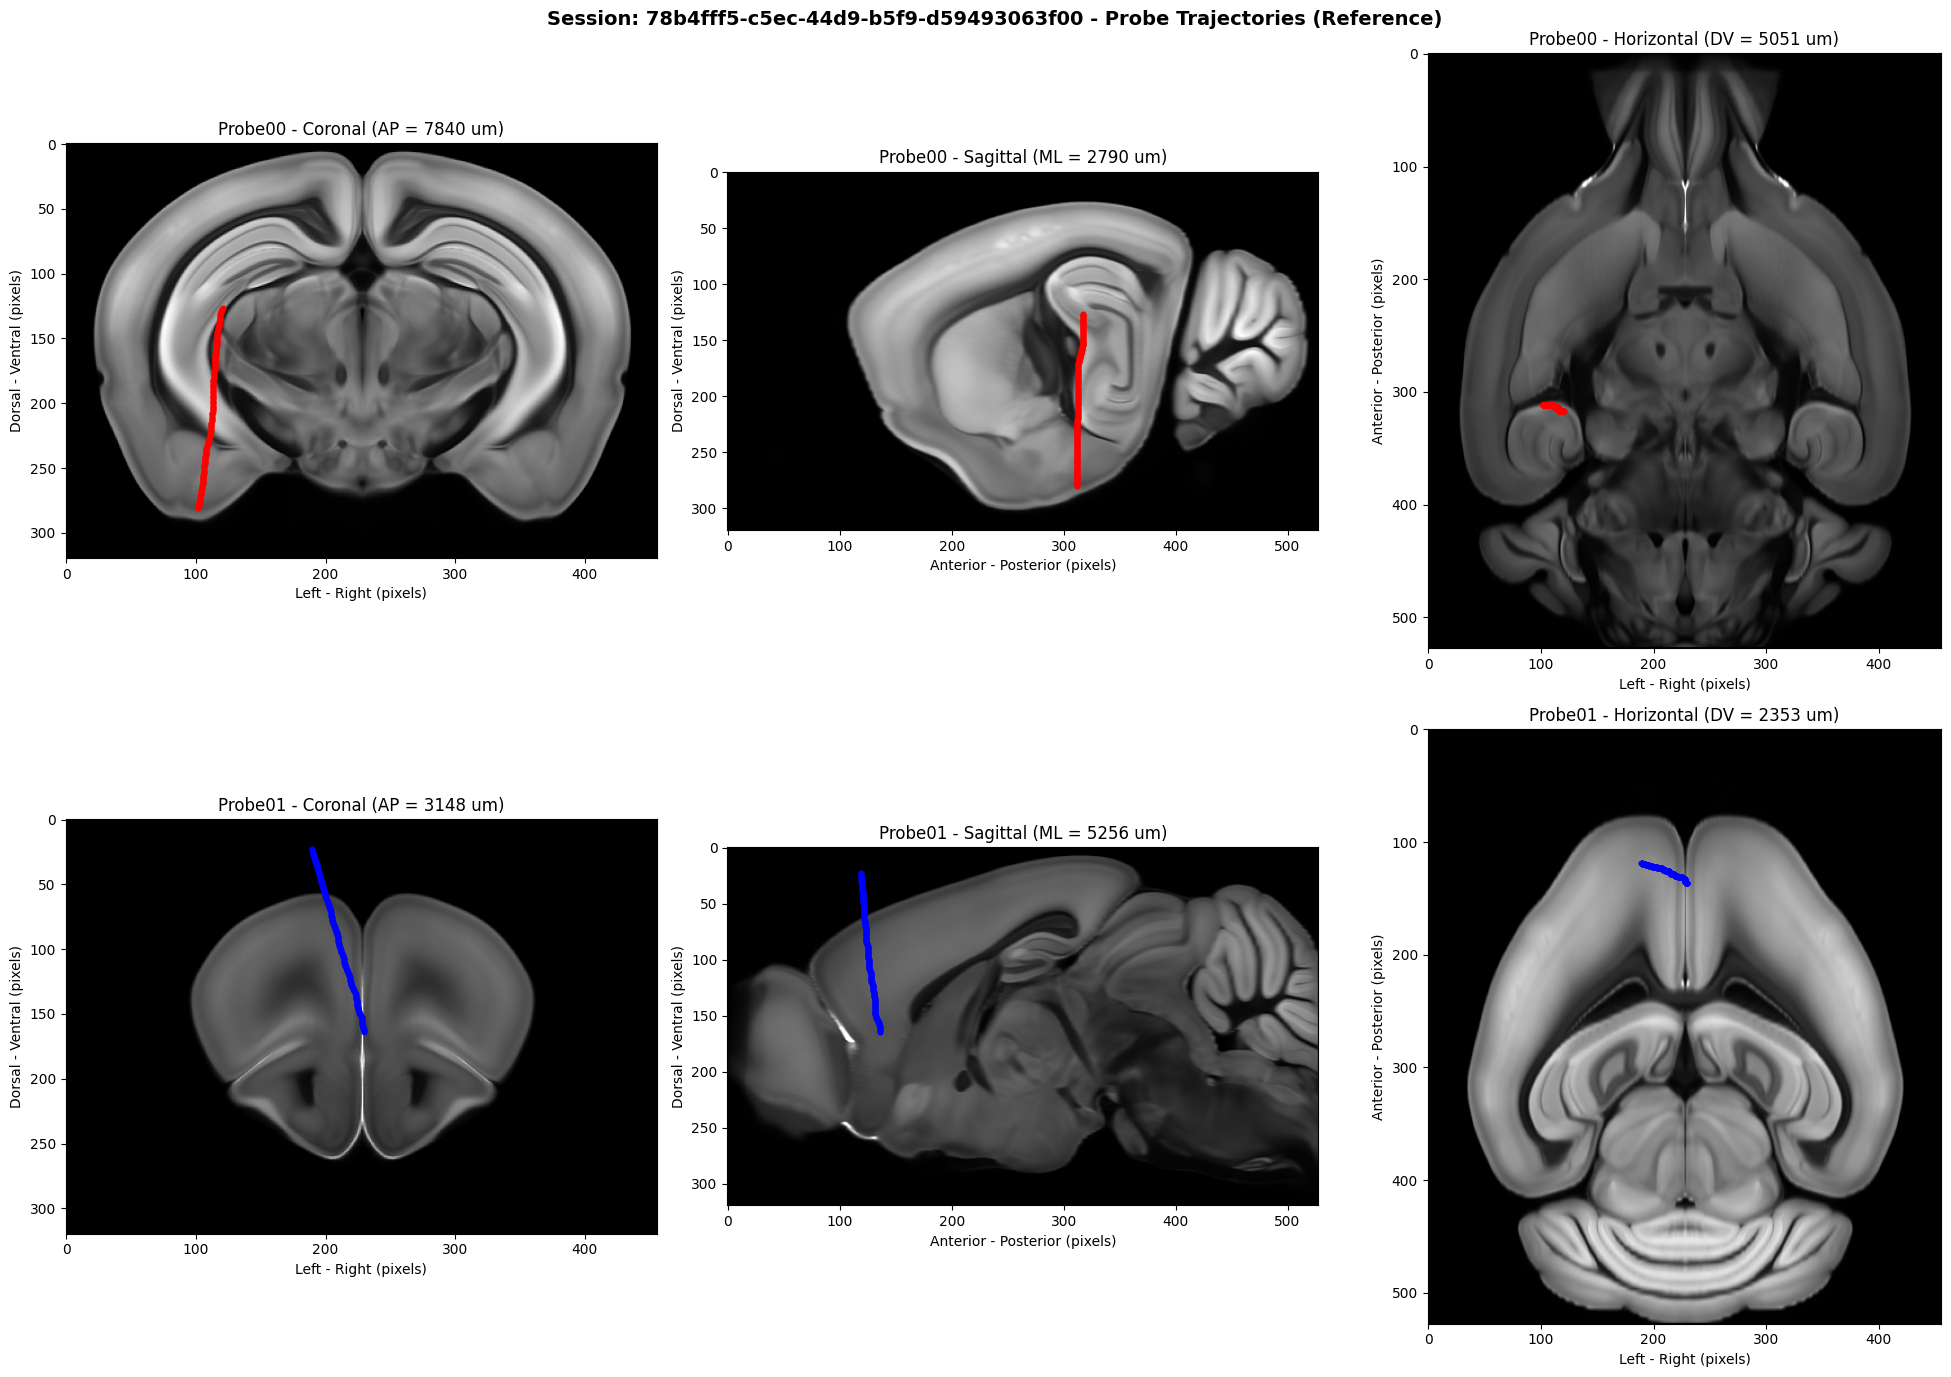

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from brainglobe_atlasapi import BrainGlobeAtlas

# %% Get CCFv3 coordinates for all probes
anatomical_tables = localization.anatomical_coordinates_tables
ccf_table_df = anatomical_tables["ElectrodesCCFv3"].to_dataframe()

# Get all unique probe names
probe_names = sorted(ccf_table_df["probe_name"].unique())
n_probes = len(probe_names)

# Define colors for each probe
probe_colors = ["red", "blue", "green", "orange", "purple"][:n_probes]

# %% Load atlas
atlas = BrainGlobeAtlas("allen_mouse_25um")

# %% Collect probe data - compute slice positions per probe (mean coordinate approach)
# See documentation/probe_slice_visualization_guide.md for heuristics
probe_data = {}

for probe_name in probe_names:
    probe_table = ccf_table_df[ccf_table_df["probe_name"] == probe_name].copy()
    bg_x = probe_table["x"].values  # Anterior (0) to Posterior (13200)
    bg_y = probe_table["y"].values  # Dorsal (0) to Ventral (8000)
    bg_z = probe_table["z"].values  # Left (0) to Right (11400)
    
    # Calculate slice positions for this specific probe (mean coordinate)
    coronal_position = int(np.mean(bg_x))
    sagittal_position = int(np.mean(bg_z))
    horizontal_position = int(np.mean(bg_y))
    
    # Convert to slice indices
    coronal_index = int(coronal_position / atlas.resolution[0])
    sagittal_index = int(sagittal_position / atlas.resolution[2])
    horizontal_index = int(horizontal_position / atlas.resolution[1])
    
    probe_data[probe_name] = {
        "x_px": bg_x / atlas.resolution[0],
        "y_px": bg_y / atlas.resolution[1],
        "z_px": bg_z / atlas.resolution[2],
        "coronal_position": coronal_position,
        "sagittal_position": sagittal_position,
        "horizontal_position": horizontal_position,
        "coronal_index": coronal_index,
        "sagittal_index": sagittal_index,
        "horizontal_index": horizontal_index,
    }

# %% Create Figure: Grid with n_probes rows x 3 columns (one row per probe)
fig, axes = plt.subplots(n_probes, 3, figsize=(20, 7 * n_probes))

# Handle single probe case (axes won't be 2D)
if n_probes == 1:
    axes = axes.reshape(1, -1)

for row, probe_name in enumerate(probe_names):
    data = probe_data[probe_name]
    color = probe_colors[row]
    
    # Get slices centered on this probe's location
    reference_coronal = atlas.reference[data["coronal_index"], :, :]
    reference_sagittal = atlas.reference[:, :, data["sagittal_index"]]
    reference_horizontal = atlas.reference[:, data["horizontal_index"], :]
    
    # Coronal view
    ax = axes[row, 0]
    ax.imshow(reference_coronal, cmap="gray", aspect="equal")
    ax.scatter(data["z_px"], data["y_px"], c=color, s=10, alpha=0.8)
    ax.set_xlabel("Left - Right (pixels)")
    ax.set_ylabel("Dorsal - Ventral (pixels)")
    ax.set_title(f"{probe_name} - Coronal (AP = {data['coronal_position']} um)")
    
    # Sagittal view (transposed for correct orientation)
    ax = axes[row, 1]
    ax.imshow(reference_sagittal.T, cmap="gray", aspect="equal")
    ax.scatter(data["x_px"], data["y_px"], c=color, s=10, alpha=0.8)
    ax.set_xlabel("Anterior - Posterior (pixels)")
    ax.set_ylabel("Dorsal - Ventral (pixels)")
    ax.set_title(f"{probe_name} - Sagittal (ML = {data['sagittal_position']} um)")
    
    # Horizontal view
    ax = axes[row, 2]
    ax.imshow(reference_horizontal, cmap="gray", aspect="equal")
    ax.scatter(data["z_px"], data["x_px"], c=color, s=10, alpha=0.8)
    ax.set_xlabel("Left - Right (pixels)")
    ax.set_ylabel("Anterior - Posterior (pixels)")
    ax.set_title(f"{probe_name} - Horizontal (DV = {data['horizontal_position']} um)")

fig.suptitle(f"Session: {nwbfile_raw.session_id} - Probe Trajectories (Reference)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Both the electrode and the anatomical coordinates tables are present both nwbfiles (the one with the raw data and the one with the processed data) and are identical in both files.

## Accessing Video Data

In [15]:
from pathlib import Path
from pynwb.image import ImageSeries

# Videos in NWB are stored as ImageSeries with external_file containing relative paths
# We resolve them to full DANDI asset paths and get S3 URLs for streaming

nwb_parent = Path(raw_asset.path).parent
video_s3_urls = {}

for name, obj in nwbfile_raw.acquisition.items():
    # Check for ImageSeries with external_file (videos stored externally)
    if isinstance(obj, ImageSeries) and obj.external_file is not None:
        # Get the relative path and resolve to full DANDI path
        relative_path = obj.external_file[0].lstrip("./")
        full_path = str(nwb_parent / relative_path)
        
        # Fetch the video asset and get its S3 URL
        video_asset = dandiset.get_asset_by_path(full_path)
        if video_asset is not None:
            video_s3_urls[name] = video_asset.get_content_url(
                follow_redirects=1, strip_query=True
            )

video_s3_urls

{'VideoBodyCamera': 'https://dandiarchive.s3.amazonaws.com/blobs/710/ab6/710ab6a6-0092-463d-80d7-c7c19966a380',
 'VideoLeftCamera': 'https://dandiarchive.s3.amazonaws.com/blobs/8bd/94f/8bd94ffa-07c3-4889-9ee8-adf26f1761b2',
 'VideoRightCamera': 'https://dandiarchive.s3.amazonaws.com/blobs/c9f/c05/c9fc050a-a7f0-4d97-bd87-a076eb483e8a'}

In [ ]:
# Stream a video directly in the notebook using IPython HTML display
# This works but might have limitations in some notebook environments
from IPython.display import HTML

camera_to_display = "VideoLeftCamera"

if camera_to_display in video_s3_urls:
    video_url = video_s3_urls[camera_to_display]
    display(HTML(f"""
    <video width="640" height="480" controls>
        <source src="{video_url}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    <p><b>{camera_to_display}</b></p>
    """))
else:
    print(f"{camera_to_display} not available for this session")

While IPython's HTML display works for basic video playback, anywidget provides a more robust, cross-platform solution. The package [nwb-video-widgets](https://github.com/catalystneuro/nwb-video-widgets) offers a suite of widgets specifically designed for NWB video data that synchronize playback with timestamps and support multiple video streams. Here's how to use it:

In [ ]:
from nwb_video_widgets import NWBDANDIVideoPlayer

video_grid=[["VideoLeftCamera", "VideoBodyCamera", "VideoRightCamera"]]
NWBDANDIVideoPlayer(asset=raw_asset, nwbfile=nwbfile_raw, video_grid = video_grid)

# Processed files

The processed file contains the processed data including the spike sorting results, the trials information, the pose estimation results, the wheel position, lick times and other behavioral data.

In [ ]:
s3_url = processed_asset.get_content_url(follow_redirects=1, strip_query=False)
file_system = remfile.File(s3_url)
file = h5py.File(file_system, mode="r")

io = NWBHDF5IO(file=file)
nwbfile_processed = io.read()

In [ ]:
nwbfile_processed

We can get general information about the session as follows:

In [ ]:
session_start_time = nwbfile_processed.session_start_time
eid = nwbfile_processed.session_id
number_of_trials = len(nwbfile_processed.trials)
number_of_units = len(nwbfile_processed.units)
lab = nwbfile_processed.lab

print(f"Session ID: {eid}")
print(f"Session Start Time: {session_start_time}")
print(f"Number of Trials: {number_of_trials}")
print(f"Number of Units: {number_of_units}")
print(f"Lab: {lab}")

And the subject information is contained in the subject attribute:

In [ ]:
subject = nwbfile_processed.subject
subject

## Epochs (Task vs Passive)

In [ ]:
nwbfile.epochs

In [ ]:
epochs_df = nwbfile.epochs.to_dataframe()
epochs_df

## Loading Spike Sorting Data
The spike sorting results are stored in the units table. This table contains all the relevant information about each of the detected units including their spike times, waveform properties, quality metrics, and electrode provenance. The later can be used to link each unit to the corresponding electrode in the electrodes table which in turn can be used to link the unit to its anatomical location.

In [ ]:
units = nwbfile_processed.units
units


As usual we can convert the units table to a pandas dataframe for easier access and manipulation:

In [ ]:
units_df = units.to_dataframe()
units_df.columns

The following are particularly useful columns in the units table:

* **spike_times**: the spike times (in seconds) for each units referenced to the common clock of the NWB file (session start time)
* **waveform_mean**: the average waveform of the unit across all spikes as calculated by the IBL spike sorting pipeline
* **probe_name**: the name of the probe where the unit was detected. 
* **max_electrodes**: the electrode where the unit has the maximum amplitude. This is a dynamic table region that can be used to link the unit to its anatomical location via the electrodes table.
* **electrodes**: all the electrodes assigned to the unit by the IBL team. This is a dynamic table region that links back to the electrodes table in the NWB file.
* **ibl_quality_score**: Proportion of IBL quality metrics passed (0.0, 0.33, 0.67, or 1.0). 1.0 = all three passed.

In the following we analyze and visualize the spike sorting results for one of the probes in the session.

In [ ]:
units_probe_df = units_df[units_df["probe_name"] == "Probe00"]
columns = ["unit_name", "cluster_uuid", "spike_count", "firing_rate", "kilosort2_label", "ibl_quality_score"]
units_probe_df[columns].sample(n=5)

In [ ]:
columns = ["unit_name", "median_spike_amplitude_uV", "distance_from_probe_tip_um"]
units_probe_df[columns].sample(n=5)

In [ ]:
task_epoch = epochs_df[epochs_df['protocol_type'] == 'task'].iloc[0]
passive_epoch = epochs_df[epochs_df['protocol_type'] == 'passive'].iloc[0]

# Calculate durations for labels
task_duration = task_epoch['stop_time'] - task_epoch['start_time']
passive_duration = passive_epoch['stop_time'] - passive_epoch['start_time']

# Filter to good units only (IBL quality score == 1)
df = units_probe_df[units_probe_df['ibl_quality_score'] == 1].copy()
print(f"Number of good units on {probe_name}: {len(units_probe_df[units_probe_df['ibl_quality_score'] == 1])}")

# Sort units by depth
units_probe = df.sort_values('distance_from_probe_tip_um')

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Add epoch background colors with duration in labels
ax.axvspan(task_epoch['start_time'], task_epoch['stop_time'],
           color='lightblue', alpha=0.3, label=f'Task ({task_duration/60:.1f} min)')
ax.axvspan(passive_epoch['start_time'], passive_epoch['stop_time'],
           color='lightyellow', alpha=0.3, label=f'Passive ({passive_duration/60:.1f} min)')

# Plot spikes for each unit at its depth
for idx, (unit_id, unit) in enumerate(units_probe.iterrows()):
    spike_times = unit['spike_times']
    depth = unit['distance_from_probe_tip_um']

    # Plot all spikes
    ax.scatter(spike_times, np.full(len(spike_times), depth),
               c='black', s=1.0, marker='|', linewidths=0.5, alpha=0.5)

# Add epoch boundary line
ax.axvline(task_epoch['stop_time'], color='red', linestyle='--', linewidth=1.5, label='Task/Passive boundary')

# Labels and styling
ax.set_xlabel('Time (s)')
ax.set_ylabel('Distance From Probe Tip (um)')
ax.set_title(f'Spike Raster by Depth - {probe_name} (good units only)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, passive_epoch['stop_time'])
ax.set_ylim(0, units_probe['distance_from_probe_tip_um'].max() + 100)

# Keep y-axis normal (depth increases upward, deeper units at top)

# Add legend outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 9), sharey=True)

# Left plot - colored by kilosort2_label
df = units_probe_df
value_to_color = {"mua": "red", "good": "green"}

for label, color in value_to_color.items():
    subset = df[df["kilosort2_label"] == label]
    axes[0].scatter(
        subset["median_spike_amplitude_uV"],
        subset["distance_from_probe_tip_um"],
        c=color,
        label=label,
        s=100,
    )
axes[0].set_xlim([0, 800])
axes[0].set_xlabel("median_spike_amplitude_uV")
axes[0].set_ylabel("mean_relative_depth_um")
axes[0].set_title("By Kilosort2 Label")
axes[0].legend()

# Right plot - colored by firing_rate
df = units_probe_df[units_probe_df["ibl_quality_score"] == 1]

df.plot.scatter(
    x="median_spike_amplitude_uV", 
    y="distance_from_probe_tip_um",
    c="firing_rate",
    colormap="inferno",
    s=100,
    ax=axes[1]
)
axes[1].set_xlim([0, 800])
axes[1].set_xlabel("median_spike_amplitude_uV")
axes[1].set_title("By Firing Rate (Quality=1)")

plt.tight_layout()
plt.show()


### Accessing Waveform Data

The units table contains mean waveform data stored as `waveform_mean` - a 2D array with shape `(num_samples, num_channels)` for each unit. These are the average spike shapes computed by IBL's spike sorting pipeline:

- **Sampling rate**: 30 kHz
- **82 time samples**: ~2.7 ms window centered on spike time  
- **32 channels per unit**: Subset of probe channels around the max amplitude channel, ordered by proximity to max channel (not by depth)
- **Values in microvolts (uV)**

The electrodes associated with each unit are stored in the `electrodes` column, which provides the channel positions (`rel_y`) needed to reorder waveforms by depth for visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from ibl_to_nwb.utils import COSMOS_FULL_NAMES, get_cosmos_color


def get_cosmos_region_data(probe_table):
    """Extract COSMOS region blocks from probe table for visualization."""
    probe_table = probe_table.sort_values("rel_y").reset_index(drop=True)
    cosmos_values = probe_table["cosmos_location"].values
    rel_y_values = probe_table["rel_y"].values

    blocks = []
    current_region = cosmos_values[0]
    block_start = rel_y_values[0]

    for i in range(1, len(cosmos_values)):
        if cosmos_values[i] != current_region:
            block_end = (rel_y_values[i - 1] + rel_y_values[i]) / 2
            blocks.append((current_region, block_start, block_end))
            current_region = cosmos_values[i]
            block_start = block_end

    blocks.append((current_region, block_start, rel_y_values[-1] + 5))

    unique_regions = []
    for region, _, _ in blocks:
        if region not in unique_regions:
            unique_regions.append(region)

    return blocks, unique_regions


def plot_probe_regions(probe_table, ax, unit_depths=None, unit_ids=None):
    """Plot probe with COSMOS region strip and electrode contacts."""
    probe_table = probe_table.sort_values("rel_y").reset_index(drop=True)
    rel_x_values = probe_table["rel_x"].values
    rel_y_values = probe_table["rel_y"].values

    x_min, x_max = rel_x_values.min(), rel_x_values.max()
    y_min, y_max = rel_y_values.min(), rel_y_values.max()

    blocks, unique_regions = get_cosmos_region_data(probe_table)
    strip_width = x_max - x_min + 30
    strip_x = x_min - 15

    for region, y_start, y_end in blocks:
        color = get_cosmos_color(region)
        rect = plt.Rectangle(
            (strip_x, y_start), strip_width, y_end - y_start, facecolor=color, edgecolor="none", alpha=0.5
        )
        ax.add_patch(rect)

    for i in range(len(rel_x_values)):
        rect = plt.Rectangle(
            (rel_x_values[i] - 6, rel_y_values[i] - 5), 12, 10, facecolor="white", edgecolor="black", linewidth=0.3
        )
        ax.add_patch(rect)

    if unit_depths is not None and unit_ids is not None:
        for i, depth in enumerate(unit_depths):
            if i < len(unit_ids):
                ax.text(x_max + 25, depth, str(unit_ids[i]), va="center", ha="left", fontsize=7, color="black", fontweight="bold")

    ax.set_xlim(x_min - 50, x_max + 50)
    ax.set_ylim(y_min - 100, y_max + 100)
    ax.set_xticks([])
    ax.set_ylabel("Depth (um)")
    ax.set_aspect("equal", adjustable="box")
    for spine in ax.spines.values():
        spine.set_visible(False)

    legend_handles = [
        Patch(facecolor=get_cosmos_color(r), edgecolor="black", linewidth=0.5, label=COSMOS_FULL_NAMES.get(r, r), alpha=0.5)
        for r in unique_regions
    ]
    return ax, legend_handles


def plot_waveform_wiggle(waveform_uV, electrode_depths, ax, fs=30000.0, gain=0.4, channel_spacing=0.8):
    """Plot waveform as IBL-style double wiggle plot.

    Parameters
    ----------
    waveform_uV : array
        Waveform data in microvolts (num_samples, num_channels).
    electrode_depths : array
        Depth of each electrode channel.
    ax : matplotlib axis
    fs : float
        Sampling rate in Hz.
    gain : float
        Scaling factor for waveform amplitude.
    channel_spacing : float
        Vertical spacing between channels.
    """
    num_samples, num_channels = waveform_uV.shape

    # Handle mismatch between waveform channels and electrode depths
    n_electrodes = len(electrode_depths)
    if num_channels != n_electrodes:
        # Use only channels that have electrode depths
        num_channels = min(num_channels, n_electrodes)
        waveform_uV = waveform_uV[:, :num_channels]
        electrode_depths = electrode_depths[:num_channels]

    center_sample = num_samples // 2
    time_ms = (np.arange(num_samples) - center_sample) / fs * 1000

    sort_order = np.argsort(electrode_depths)
    wf_sorted = waveform_uV[:, sort_order]
    depths_sorted = electrode_depths[sort_order]

    wf_max = np.abs(wf_sorted).max()
    wf_norm = wf_sorted / wf_max * gain if wf_max > 0 else wf_sorted

    for ch in range(num_channels):
        offset = ch * channel_spacing
        trace = wf_norm[:, ch]
        ax.plot(time_ms, trace + offset, color="black", linewidth=0.5)
        ax.fill_between(time_ms, offset, trace + offset, where=(trace > 0), color="orange", alpha=0.8, linewidth=0)
        ax.fill_between(time_ms, offset, trace + offset, where=(trace < 0), color="slateblue", alpha=0.8, linewidth=0)

    ax.set_xlabel("Time (ms)")
    depth_ticks = np.linspace(depths_sorted.min(), depths_sorted.max(), 5)
    channel_positions = np.linspace(0, (num_channels - 1) * channel_spacing, 5)
    ax.set_yticks(channel_positions)
    ax.set_yticklabels([f"{d:.0f}" for d in depth_ticks])
    ax.set_ylabel("Distance from tip (um)")


def get_max_channel_index(unit):
    """Get the index (0-31) of the max electrode within the unit's electrodes list."""
    max_electrode_idx = unit["max_electrode"].index[0]
    electrodes_indices = unit["electrodes"].index.tolist()
    if max_electrode_idx in electrodes_indices:
        return electrodes_indices.index(max_electrode_idx)
    waveform = unit["waveform_mean"]
    peak_to_peak = waveform.max(axis=0) - waveform.min(axis=0)
    return np.argmax(peak_to_peak)


def plot_max_channel_waveform(waveform_uV, ax, max_ch_idx=None, fs=30000.0):
    """Plot waveform on the max amplitude channel.

    Parameters
    ----------
    waveform_uV : array
        Waveform data in microvolts (num_samples, num_channels).
    ax : matplotlib axis
    max_ch_idx : int, optional
        Index of max channel in the waveform array. If None, computed from waveform.
    fs : float
        Sampling rate in Hz.
    """
    num_samples = waveform_uV.shape[0]
    center_sample = num_samples // 2
    time_ms = (np.arange(num_samples) - center_sample) / fs * 1000

    if max_ch_idx is None:
        peak_to_peak = waveform_uV.max(axis=0) - waveform_uV.min(axis=0)
        max_ch_idx = np.argmax(peak_to_peak)

    trace = waveform_uV[:, max_ch_idx]

    ax.plot(time_ms, trace, color="black", linewidth=1.0)
    ax.fill_between(time_ms, 0, trace, where=(trace > 0), color="orange", alpha=0.8, linewidth=0)
    ax.fill_between(time_ms, 0, trace, where=(trace < 0), color="slateblue", alpha=0.8, linewidth=0)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (uV)")


def plot_waveform_heatmap(waveform_uV, electrode_depths, ax, fs=30000.0, vmax=None, add_colorbar=False):
    """Plot waveform as a heatmap (time x channel).

    Parameters
    ----------
    waveform_uV : array
        Waveform data in microvolts (num_samples, num_channels).
    electrode_depths : array
        Depth of each electrode channel.
    ax : matplotlib axis
    fs : float
        Sampling rate in Hz.
    vmax : float, optional
        Max value for colormap.
    add_colorbar : bool
        Whether to add a colorbar.
    """
    num_samples, num_channels = waveform_uV.shape

    # Handle mismatch between waveform channels and electrode depths
    n_electrodes = len(electrode_depths)
    if num_channels != n_electrodes:
        num_channels = min(num_channels, n_electrodes)
        waveform_uV = waveform_uV[:, :num_channels]
        electrode_depths = electrode_depths[:num_channels]

    center_sample = num_samples // 2
    time_ms = (np.arange(num_samples) - center_sample) / fs * 1000

    sort_order = np.argsort(electrode_depths)
    wf_sorted = waveform_uV[:, sort_order]
    depths_sorted = electrode_depths[sort_order]

    if vmax is None:
        vmax = np.abs(wf_sorted).max()

    im = ax.imshow(
        wf_sorted.T,
        aspect="auto",
        origin="lower",
        extent=[time_ms[0], time_ms[-1], 0, num_channels],
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_xlabel("Time (ms)")

    depth_ticks = np.linspace(depths_sorted.min(), depths_sorted.max(), 5)
    channel_positions = np.linspace(0, num_channels, 5)
    ax.set_yticks(channel_positions)
    ax.set_yticklabels([f"{d:.0f}" for d in depth_ticks])
    ax.set_ylabel("Distance from tip (um)")

    if add_colorbar:
        plt.colorbar(im, ax=ax, label="Amplitude (uV)")
    return im

In [ ]:
# %% Select good units and create combined waveform visualization
# Get localization data for probe visualization
localization = nwbfile_processed.lab_meta_data.get("localization")
anatomical_tables = localization.anatomical_coordinates_tables
ibl_bregma_table_df = anatomical_tables["ElectrodesIBLBregma"].to_dataframe()

# Extract electrode positions from localized_entity
ibl_bregma_table_df["rel_x"] = [electrode["rel_x"].iloc[0] for electrode in ibl_bregma_table_df["localized_entity"]]
ibl_bregma_table_df["rel_y"] = [electrode["rel_y"].iloc[0] for electrode in ibl_bregma_table_df["localized_entity"]]

# Select good units from first probe
probe_name = "Probe00"
good_units = units_df[(units_df["probe_name"] == probe_name) & (units_df["ibl_quality_score"] == 1.0)].copy()

if len(good_units) == 0:
    probe_name = "Probe01"
    good_units = units_df[(units_df["probe_name"] == probe_name) & (units_df["ibl_quality_score"] == 1.0)].copy()

good_units = good_units.sort_values("distance_from_probe_tip_um")
probe_table = ibl_bregma_table_df[ibl_bregma_table_df["probe_name"] == probe_name].copy()

# Filter out units with any NaN waveforms (some units have partial NaN data)
valid_waveform_mask = [not np.isnan(unit["waveform_mean"]).any() for _, unit in good_units.iterrows()]
good_units = good_units[valid_waveform_mask]

print(f"Selected {len(good_units)} good units with valid waveforms from {probe_name}")

# Select 3 units evenly spaced across depth
depths = good_units["distance_from_probe_tip_um"].values
target_depths = np.linspace(depths.min(), depths.max(), 3)
selected_indices = []
available_mask = np.ones(len(good_units), dtype=bool)

for target in target_depths:
    available_depths = depths.copy()
    available_depths[~available_mask] = np.inf
    closest_idx = np.argmin(np.abs(available_depths - target))
    selected_indices.append(closest_idx)
    available_mask[closest_idx] = False

selected_indices = sorted(selected_indices, key=lambda i: depths[i])
example_units = good_units.iloc[selected_indices]
example_depths = example_units["distance_from_probe_tip_um"].values.tolist()
example_unit_ids = example_units.index.tolist()

# Convert waveforms from volts to microvolts for visualization
# NWB schema has waveform_mean unit fixed to 'volts', so we always convert to uV for display
conversion_factor = 1e6
print("Converting waveforms from volts to microvolts for display (factor: 1e6)")

# Compute shared vmax for heatmaps (in microvolts)
shared_vmax = max(np.abs(unit["waveform_mean"] * conversion_factor).max() for _, unit in example_units.iterrows())

# Create combined figure: Probe | 3x3 waveforms | colorbar
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 5, width_ratios=[1.0, 1.2, 1.2, 1.2, 0.08], wspace=0.35, hspace=0.4)

# Probe visualization (spans all 3 rows)
ax_probe = fig.add_subplot(gs[:, 0])
_, legend_handles = plot_probe_regions(probe_table, ax_probe, unit_depths=example_depths, unit_ids=example_unit_ids)
ax_probe.set_title(f"{probe_name}\nElectrode Contacts", fontsize=10)

if legend_handles:
    ax_probe.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
                    ncol=2, fontsize=6, frameon=False, title="COSMOS Regions", title_fontsize=7)

# Store last heatmap image for shared colorbar
last_heatmap_im = None

# Plot waveforms for each unit (columns 1-3)
for col_idx, (unit_id, unit) in enumerate(example_units.iterrows()):
    # Convert waveform to microvolts for visualization
    waveform_uV = unit["waveform_mean"] * conversion_factor
    depth = unit["distance_from_probe_tip_um"]
    region = unit["max_electrode"]["location"].values[0]
    electrode_depths = unit["electrodes"]["rel_y"].values
    
    # Get max channel index from the unit's electrode mapping
    max_ch_idx = get_max_channel_index(unit)
    max_electrode_depth = unit["max_electrode"]["rel_y"].values[0]

    # Row 0: Wiggle plot
    ax_wiggle = fig.add_subplot(gs[0, col_idx + 1])
    plot_waveform_wiggle(waveform_uV, electrode_depths, ax_wiggle, gain=0.4, channel_spacing=0.8)
    ax_wiggle.set_title(f"Unit {unit_id}\n{region}", fontsize=8)

    # Row 1: Max channel waveform (use max_electrode depth in title)
    ax_max = fig.add_subplot(gs[1, col_idx + 1])
    plot_max_channel_waveform(waveform_uV, ax_max, max_ch_idx=max_ch_idx)
    ax_max.set_title(f"Max electrode depth: {max_electrode_depth:.0f} um", fontsize=8)

    # Row 2: Heatmap
    ax_heatmap = fig.add_subplot(gs[2, col_idx + 1])
    last_heatmap_im = plot_waveform_heatmap(waveform_uV, electrode_depths, ax_heatmap, vmax=shared_vmax)

# Add shared colorbar for heatmaps
cbar_ax = fig.add_subplot(gs[2, 4])
cbar = fig.colorbar(last_heatmap_im, cax=cbar_ax)
cbar.set_label("Amplitude (uV)", fontsize=9)

fig.suptitle(f"Waveform Visualization - {probe_name}\nSession: {nwbfile_processed.session_id}",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Loading Trials Data

In [ ]:
trials = nwbfile_processed.trials
trials

In [ ]:
trials_df = trials.to_dataframe()
trials_df

### Overview of Trials

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# %% Compute signed contrast for y-position
contrast = trials_df["gabor_stimulus_contrast"].values
side = trials_df["gabor_stimulus_side"].values
signed_contrast = np.where(side == "left", contrast, -contrast)
trials_df["signed_contrast"] = signed_contrast

# Add jitter for overlapping points
np.random.seed(42)
trials_df["y_jitter"] = signed_contrast + np.random.uniform(-3, 3, len(trials_df))

# %% Define block background colors
block_bg_colors = {
    "unbiased": "#E0E0E0",
    "left_block": "#B3D9FF",
    "right_block": "#FFD9B3",
}
block_labels = {
    "unbiased": "Unbiased (p_left=0.5)",
    "left_block": "Left block (p_left=0.8)",
    "right_block": "Right block (p_left=0.2)",
}

# %% Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot block backgrounds
block_changes = trials_df["block_index"].diff().fillna(1) != 0
block_starts = trials_df.index[block_changes].tolist()
block_starts.append(len(trials_df))

added_labels = set()
for i in range(len(block_starts) - 1):
    start_index = block_starts[i]
    end_index = block_starts[i + 1]
    block_type = trials_df.loc[start_index, "block_type"]
    label = block_labels.get(block_type) if block_type not in added_labels else None
    ax.axvspan(
        start_index,
        end_index,
        color=block_bg_colors.get(block_type, "white"),
        alpha=0.5,
        zorder=0,
        label=label,
    )
    added_labels.add(block_type)

# Plot correct trials (blue circles)
correct = trials_df[trials_df["is_mouse_rewarded"]]
ax.scatter(
    correct.index,
    correct["y_jitter"],
    marker="o",
    s=20,
    facecolors="none",
    edgecolors="blue",
    linewidths=1,
    label="Correct",
    zorder=2,
)

# Plot incorrect trials (red X)
incorrect = trials_df[~trials_df["is_mouse_rewarded"]]
ax.scatter(
    incorrect.index,
    incorrect["y_jitter"],
    color="red",
    marker="x",
    s=20,
    linewidths=1,
    label="Incorrect",
    zorder=2,
)

# Formatting
ax.set_xlabel("Trial number")
ax.set_ylabel("Signed contrast (%)")
ax.set_xlim(-5, len(trials_df) + 5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

# Session info
subject = nwbfile.subject.subject_id if nwbfile.subject else "Unknown"
session_date = nwbfile.session_start_time.strftime("%Y-%m-%d")
n_correct = len(correct)
performance = n_correct / len(trials_df) * 100

ax.set_title(f"{subject} - {session_date} ({len(trials_df)} trials, {performance:.1f}% correct)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


### Psychometric Curves

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import psychofit as psy

# %% Compute signed contrast
# Convention: positive = left stimulus, negative = right stimulus
# This ensures P(choose right) increases with signed contrast
contrast = trials_df["gabor_stimulus_contrast"].values
side = trials_df["gabor_stimulus_side"].values
signed_contrast = np.where(side == "left", contrast, -contrast)

trials_df["signed_contrast"] = signed_contrast
trials_df["chose_right"] = (trials_df["mouse_wheel_choice"] == "right").astype(int)

# %% Define block types and colors (matching IBL style)
blocks = {
    0.5: {"color": "black", "label": "p_left=0.5"},
    0.2: {"color": "tab:red", "label": "p_left=0.2"},
    0.8: {"color": "tab:blue", "label": "p_left=0.8"},
}

# %% Fit and collect data for each block
x_fit = np.linspace(-100, 100, 200)
block_results = {}

for p_left, style in blocks.items():
    block_trials = trials_df[trials_df["probability_left"] == p_left]

    if len(block_trials) == 0:
        print(f"No trials for p_left={p_left}")
        continue

    # Aggregate by contrast
    grouped = (
        block_trials.groupby("signed_contrast")
        .agg(
            n_total=("chose_right", "count"),
            p_right=("chose_right", "mean"),
        )
        .reset_index()
    )

    # Fit psychometric curve
    data = np.vstack(
        [grouped["signed_contrast"].values, grouped["n_total"].values, grouped["p_right"].values]
    )

    pars, _ = psy.mle_fit_psycho(
        data,
        P_model="erf_psycho_2gammas",
        parstart=np.array([0.0, 40.0, 0.1, 0.1]),
        parmin=np.array([-50.0, 10.0, 0.0, 0.0]),
        parmax=np.array([50.0, 50.0, 0.2, 0.2]),
        nfits=10,
    )

    y_fit = psy.erf_psycho_2gammas(pars, x_fit)

    block_results[p_left] = {
        "grouped": grouped,
        "pars": pars,
        "y_fit": y_fit,
        "n_trials": len(block_trials),
    }

# %% Plot psychometric curves for all blocks
fig, ax = plt.subplots(figsize=(8, 6))

for p_left, style in blocks.items():
    if p_left not in block_results:
        continue

    result = block_results[p_left]
    grouped = result["grouped"]
    color = style["color"]
    label = style["label"]

    # Fitted curve
    ax.plot(x_fit, result["y_fit"], color=color, linewidth=2, label=f"{label} fit")

    # Data points
    ax.scatter(
        grouped["signed_contrast"],
        grouped["p_right"],
        color=color,
        s=50,
        alpha=0.8,
        label=f"{label} data",
    )

# Formatting
ax.set_xlabel("Contrasts")
ax.set_ylabel("Probability choosing right")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


### Reaction Time by Constrast

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pynwb import read_nwb


# %% Calculate reaction time and signed contrast
trials_df["reaction_time"] = (
    trials_df["wheel_movement_onset_time"] - trials_df["gabor_stimulus_onset_time"]
)

# Signed contrast: positive = left stimulus, negative = right stimulus
contrast = trials_df["gabor_stimulus_contrast"].values
side = trials_df["gabor_stimulus_side"].values
trials_df["signed_contrast"] = np.where(side == "left", contrast, -contrast)

# Get unique contrasts sorted
contrasts = sorted(trials_df["signed_contrast"].unique())

# %% Define block styles (matching IBL and psychometric_curve.py)
blocks = {
    0.5: {"color": "black", "label": "p_left=0.5"},
    0.2: {"color": "tab:red", "label": "p_left=0.2"},
    0.8: {"color": "tab:blue", "label": "p_left=0.8"},
}

# %% Plot reaction time by contrast for each block
fig, ax = plt.subplots(figsize=(8, 6))

for p_left, style in blocks.items():
    block_trials = trials_df[trials_df["probability_left"] == p_left]

    if len(block_trials) == 0:
        continue

    # Calculate median reaction time for each contrast (robust to outliers)
    median_rt = []
    contrast_vals = []

    for c in contrasts:
        contrast_trials = block_trials[block_trials["signed_contrast"] == c]
        if len(contrast_trials) > 0:
            median_rt.append(contrast_trials["reaction_time"].median())
            contrast_vals.append(c)

    ax.plot(
        contrast_vals,
        median_rt,
        "o-",
        color=style["color"],
        label=f"{style['label']} ({len(block_trials)} trials)",
        linewidth=1.5,
        markersize=6,
    )

# Formatting
ax.set_xlabel("Contrasts")
ax.set_ylabel("Reaction time (s)")
ax.set_xlim(-110, 110)
ax.set_ylim(0, None)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


## Loading Wheel Data

In [ ]:
wheel_module = nwbfile_processed.processing["wheel"]
wheel_module

In [ ]:
wheel_position = wheel_module["WheelPosition"]
wheel_position

## Loading Pose Estimation Data

In [ ]:
pose_estimation_module = nwbfile_processed.processing["pose_estimation"]
pose_estimation_module

In [ ]:
left_camera = pose_estimation_module["LeftCamera"]
left_camera

### Overlay Pose on Video

This widget overlays DeepLabCut pose estimation keypoints on the streaming video using [anywidget](https://anywidget.dev/). 


In [ ]:
from nwb_video_widgets import NWBDANDIPoseEstimationWidget

NWBDANDIPoseEstimationWidget(
    asset=processed_asset,
    nwbfile=nwbfile_processed,
    video_asset=raw_asset,
    video_nwbfile=nwbfile_raw,

)

## Loading Passive Data

In [ ]:
passive_module = nwbfile_processed.processing["passive_protocol"]
passive_module

In [ ]:
gabor_table = passive_module["gabor_table"]
gabor_table

In [ ]:
passive_intervals = passive_module["passive_intervals"]
passive_intervals

In [ ]:
passive_task_replay = passive_module["passive_task_replay"]
passive_task_replay

## Trial-Aligned Behavioral Data

In [ ]:
# Trial-aligned left paw speed with correct/incorrect trial separation
import pynapple as nap

# Load with pynapple from memory
data = nap.NWBFile(nwbfile_processed)

# Get trials dataframe for metadata
trials_df = nwbfile_processed.trials.to_dataframe()

# Masks for correct/incorrect
correct_mask = trials_df['is_mouse_rewarded'].values

# Get left paw position and compute speed using pynapple's derivative
left_paw = data['LeftCamera/PoseEstimationSeriesLeftPaw']
velocity = left_paw.derivative()
speed_values = np.sqrt(velocity.values[:, 0]**2 + velocity.values[:, 1]**2)
speed = nap.Tsd(t=velocity.t, d=speed_values)

# Create Ts objects for stimulus onset times
stim_times = nap.Ts(t=trials_df['gabor_stimulus_onset_time'].values)
correct_stim_times = nap.Ts(t=trials_df.loc[correct_mask, 'gabor_stimulus_onset_time'].values)
incorrect_stim_times = nap.Ts(t=trials_df.loc[~correct_mask, 'gabor_stimulus_onset_time'].values)

# Use pynapple's compute_perievent_continuous to align speed around stimulus onset
minmax = (-0.5, 1.0)  # 0.5s before to 1s after stimulus

perievent_all = nap.compute_perievent_continuous(speed, stim_times, minmax=minmax)
perievent_correct = nap.compute_perievent_continuous(speed, correct_stim_times, minmax=minmax)
perievent_incorrect = nap.compute_perievent_continuous(speed, incorrect_stim_times, minmax=minmax)

# Compute mean and SEM
correct_mean = np.nanmean(perievent_correct.values, axis=1)
correct_sem = np.nanstd(perievent_correct.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_correct.values), axis=1))
incorrect_mean = np.nanmean(perievent_incorrect.values, axis=1)
incorrect_sem = np.nanstd(perievent_incorrect.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_incorrect.values), axis=1))

time = perievent_correct.t

# Sort trials by outcome for raster
sorted_indices = np.argsort(correct_mask)
perievent_sorted = perievent_all.values[:, sorted_indices]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time, correct_mean, color='blue', linewidth=1.5, label='Correct')
ax_avg.fill_between(time, correct_mean - correct_sem, correct_mean + correct_sem, color='blue', alpha=0.3)
ax_avg.plot(time, incorrect_mean, color='red', linewidth=1.5, label='Incorrect')
ax_avg.fill_between(time, incorrect_mean - incorrect_sem, incorrect_mean + incorrect_sem, color='red', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.set_ylabel('Speed (px/s)')
ax_avg.set_title('Left paw speed', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

ax_raster = axes[1]
n_trials = perievent_sorted.shape[1]
n_incorrect = (~correct_mask).sum()
n_correct = correct_mask.sum()

im = ax_raster.imshow(perievent_sorted.T, aspect='auto', cmap='gray_r',
                       extent=[time[0], time[-1], 0, n_trials],
                       vmin=0, vmax=np.nanpercentile(perievent_sorted, 95),
                       origin='lower')

# Side color bar
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_incorrect / n_trials, color='red', alpha=0.8)
ax_bar.axhspan(n_incorrect / n_trials, 1, color='blue', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_incorrect / n_trials) / 2, 'incorrect', rotation=90, va='center', ha='left', fontsize=9, color='red', fontweight='bold')
ax_bar.text(1.5, n_incorrect / n_trials + (n_correct / n_trials) / 2, 'correct', rotation=90, va='center', ha='left', fontsize=9, color='blue', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from Stim On (s)')

plt.tight_layout()
plt.show()

In [ ]:
# Trial-aligned pupil diameter (z-scored) with correct/incorrect trial separation

# Get smoothed pupil diameter
pupil = data['LeftPupilDiameterSmoothed']

# Create Ts objects for stimulus onset times
stim_times = nap.Ts(t=trials_df['gabor_stimulus_onset_time'].values)
correct_stim_times = nap.Ts(t=trials_df.loc[correct_mask, 'gabor_stimulus_onset_time'].values)
incorrect_stim_times = nap.Ts(t=trials_df.loc[~correct_mask, 'gabor_stimulus_onset_time'].values)

minmax = (-0.5, 1.0)

perievent_all = nap.compute_perievent_continuous(pupil, stim_times, minmax=minmax)
perievent_correct = nap.compute_perievent_continuous(pupil, correct_stim_times, minmax=minmax)
perievent_incorrect = nap.compute_perievent_continuous(pupil, incorrect_stim_times, minmax=minmax)

# Z-score the data for visualization
all_values = perievent_all.values.flatten()
all_values = all_values[~np.isnan(all_values)]
mean_val = np.mean(all_values)
std_val = np.std(all_values)

perievent_all_z = (perievent_all.values - mean_val) / std_val
perievent_correct_z = (perievent_correct.values - mean_val) / std_val
perievent_incorrect_z = (perievent_incorrect.values - mean_val) / std_val

# Compute mean and SEM
correct_mean = np.nanmean(perievent_correct_z, axis=1)
correct_sem = np.nanstd(perievent_correct_z, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_correct_z), axis=1))
incorrect_mean = np.nanmean(perievent_incorrect_z, axis=1)
incorrect_sem = np.nanstd(perievent_incorrect_z, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_incorrect_z), axis=1))

time = perievent_correct.t

# Sort trials by outcome for raster
sorted_indices = np.argsort(correct_mask)
perievent_sorted = perievent_all_z[:, sorted_indices]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time, correct_mean, color='blue', linewidth=1.5, label='Correct')
ax_avg.fill_between(time, correct_mean - correct_sem, correct_mean + correct_sem, color='blue', alpha=0.3)
ax_avg.plot(time, incorrect_mean, color='red', linewidth=1.5, label='Incorrect')
ax_avg.fill_between(time, incorrect_mean - incorrect_sem, incorrect_mean + incorrect_sem, color='red', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.set_ylabel('Pupil (z-score)')
ax_avg.set_title('Pupil diameter', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

ax_raster = axes[1]
n_trials = perievent_sorted.shape[1]
n_incorrect = (~correct_mask).sum()
n_correct = correct_mask.sum()

im = ax_raster.imshow(perievent_sorted.T, aspect='auto', cmap='gray_r',
                       extent=[time[0], time[-1], 0, n_trials],
                       vmin=np.nanpercentile(perievent_sorted, 5),
                       vmax=np.nanpercentile(perievent_sorted, 95),
                       origin='lower')

# Side color bar
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_incorrect / n_trials, color='red', alpha=0.8)
ax_bar.axhspan(n_incorrect / n_trials, 1, color='blue', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_incorrect / n_trials) / 2, 'incorrect', rotation=90, va='center', ha='left', fontsize=9, color='red', fontweight='bold')
ax_bar.text(1.5, n_incorrect / n_trials + (n_correct / n_trials) / 2, 'correct', rotation=90, va='center', ha='left', fontsize=9, color='blue', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from Stim On (s)')

plt.tight_layout()
plt.show()

In [ ]:
# Trial-aligned wheel velocity sorted by choice (left/right), aligned to first movement onset

# Masks for left/right choices
left_choice_mask = trials_df['mouse_wheel_choice'].values == 'left'
right_choice_mask = trials_df['mouse_wheel_choice'].values == 'right'

# Get wheel velocity (in rad/s)
wheel_velocity = data['WheelVelocitySmoothed']

# Create Ts objects for first movement times, separated by choice
movement_times = nap.Ts(t=trials_df['wheel_movement_onset_time'].values)
left_movement_times = nap.Ts(t=trials_df.loc[left_choice_mask, 'wheel_movement_onset_time'].values)
right_movement_times = nap.Ts(t=trials_df.loc[right_choice_mask, 'wheel_movement_onset_time'].values)

minmax = (-0.5, 1.0)

perievent_all = nap.compute_perievent_continuous(wheel_velocity, movement_times, minmax=minmax)
perievent_left = nap.compute_perievent_continuous(wheel_velocity, left_movement_times, minmax=minmax)
perievent_right = nap.compute_perievent_continuous(wheel_velocity, right_movement_times, minmax=minmax)

# Compute mean and SEM
left_mean = np.nanmean(perievent_left.values, axis=1)
left_sem = np.nanstd(perievent_left.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_left.values), axis=1))
right_mean = np.nanmean(perievent_right.values, axis=1)
right_sem = np.nanstd(perievent_right.values, axis=1) / np.sqrt(np.sum(~np.isnan(perievent_right.values), axis=1))

time = perievent_left.t

# Sort trials by choice for raster (left first, then right)
sorted_indices = np.argsort(right_choice_mask)  # False (left) first, then True (right)
perievent_sorted = perievent_all.values[:, sorted_indices]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time, left_mean, color='green', linewidth=1.5, label='Left')
ax_avg.fill_between(time, left_mean - left_sem, left_mean + left_sem, color='green', alpha=0.3)
ax_avg.plot(time, right_mean, color='olive', linewidth=1.5, label='Right')
ax_avg.fill_between(time, right_mean - right_sem, right_mean + right_sem, color='olive', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax_avg.set_ylabel('Velocity (rad/s)')
ax_avg.set_title('Wheel velocity', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

ax_raster = axes[1]
n_trials = perievent_sorted.shape[1]
n_left = left_choice_mask.sum()
n_right = right_choice_mask.sum()

im = ax_raster.imshow(perievent_sorted.T, aspect='auto', cmap='gray_r',
                       extent=[time[0], time[-1], 0, n_trials],
                       vmin=np.nanpercentile(perievent_sorted, 5),
                       vmax=np.nanpercentile(perievent_sorted, 95),
                       origin='lower')

# Side color bar for left/right choice
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_left / n_trials, color='green', alpha=0.8)
ax_bar.axhspan(n_left / n_trials, 1, color='olive', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_left / n_trials) / 2, 'left', rotation=90, va='center', ha='left', fontsize=9, color='green', fontweight='bold')
ax_bar.text(1.5, n_left / n_trials + (n_right / n_trials) / 2, 'right', rotation=90, va='center', ha='left', fontsize=9, color='olive', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from First Move (s)')

plt.tight_layout()
plt.show()

In [ ]:
# Trial-aligned lick counts with correct/incorrect trial separation, aligned to feedback time

# Get lick timestamps from processing module
lick_events = nwbfile_processed.processing['lick_times']['EventsLickTimes']
lick_times = nap.Ts(t=lick_events.timestamps[:])

# Create Ts objects for feedback times
feedback_times = nap.Ts(t=trials_df['feedback_time'].values)
correct_feedback_times = nap.Ts(t=trials_df.loc[correct_mask, 'feedback_time'].values)
incorrect_feedback_times = nap.Ts(t=trials_df.loc[~correct_mask, 'feedback_time'].values)

minmax = (-0.5, 1.0)
bin_size = 0.02  # 20ms bins for counting

# Use compute_perievent to align lick timestamps around feedback
perievent_licks = nap.compute_perievent(lick_times, feedback_times, minmax=minmax)

# For the average trace, we need to count licks in bins
perievent_correct_licks = nap.compute_perievent(lick_times, correct_feedback_times, minmax=minmax)
perievent_incorrect_licks = nap.compute_perievent(lick_times, incorrect_feedback_times, minmax=minmax)

# Count licks in bins for average traces
correct_counts = perievent_correct_licks.count(bin_size)
incorrect_counts = perievent_incorrect_licks.count(bin_size)

# Mean across trials (columns are trials in the TsGroup)
correct_mean = np.nanmean(correct_counts.values, axis=1)
correct_sem = np.nanstd(correct_counts.values, axis=1) / np.sqrt(correct_counts.shape[1])
incorrect_mean = np.nanmean(incorrect_counts.values, axis=1)
incorrect_sem = np.nanstd(incorrect_counts.values, axis=1) / np.sqrt(incorrect_counts.shape[1])

time_counts = correct_counts.t

# Sort trials by outcome
sorted_trial_indices = np.argsort(correct_mask)

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(4, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

ax_avg = axes[0]
ax_avg.plot(time_counts, correct_mean, color='blue', linewidth=1.5, label='Correct')
ax_avg.fill_between(time_counts, correct_mean - correct_sem, correct_mean + correct_sem, color='blue', alpha=0.3)
ax_avg.plot(time_counts, incorrect_mean, color='red', linewidth=1.5, label='Incorrect')
ax_avg.fill_between(time_counts, incorrect_mean - incorrect_sem, incorrect_mean + incorrect_sem, color='red', alpha=0.3)
ax_avg.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_avg.set_ylabel('Licks (count)')
ax_avg.set_title('Licks', fontsize=12, fontweight='bold', loc='center')
ax_avg.legend(loc='upper left', fontsize=8, framealpha=0.9)

# Raster plot - plot individual lick events
ax_raster = axes[1]

# Plot licks as scatter points for each trial
n_trials = len(trials_df)
n_incorrect = (~correct_mask).sum()
n_correct = correct_mask.sum()

# Get lick times for each trial and plot as raster
for i, sorted_index in enumerate(sorted_trial_indices):
    if sorted_index in perievent_licks.keys():
        trial_licks = perievent_licks[sorted_index]
        if len(trial_licks) > 0:
            ax_raster.scatter(trial_licks.t, np.full(len(trial_licks), i),
                            c='black', s=1, marker='|', linewidths=0.5)

# Side color bar
bar_width = 0.05
ax_bar = ax_raster.inset_axes([1.02, 0, bar_width, 1])
ax_bar.axhspan(0, n_incorrect / n_trials, color='red', alpha=0.8)
ax_bar.axhspan(n_incorrect / n_trials, 1, color='blue', alpha=0.8)
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')
ax_bar.text(1.5, (n_incorrect / n_trials) / 2, 'incorrect', rotation=90, va='center', ha='left', fontsize=9, color='red', fontweight='bold')
ax_bar.text(1.5, n_incorrect / n_trials + (n_correct / n_trials) / 2, 'correct', rotation=90, va='center', ha='left', fontsize=9, color='blue', fontweight='bold')

ax_raster.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax_raster.set_ylabel('Sorted Trial Number')
ax_raster.set_xlabel('T from Feedback (s)')
ax_raster.set_xlim(minmax[0], minmax[1])
ax_raster.set_ylim(0, n_trials)

plt.tight_layout()
plt.show()